In [9]:
import pandas as pd

df1 = pd.read_csv('Dataset of Diabetes .csv')
print("Dataset loaded successfully")
df1.head()

Dataset loaded successfully


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [12]:
print("\nDataFrame info:")
df.info()
print("\nDescriptive statistics")
print(df.describe())
print("\nMissing values per column:")
print(df.isnull().sum())


DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB

Descriptive statistics
                ID     No_Pation          AGE         Urea           Cr  \
count  1000.000000  1.000000e+03  1000.000000  1000.000000  1000.000000   

In [11]:
print("Missing values per column after inspection:")
print(df.isnull().sum())


categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nIdentified categorical columns: {list(categorical_cols)}")


for col in categorical_cols:
    print(f"\nUnique values in '{col}': {df[col].unique()}")
    print(f"Value counts for '{col}':\n{df[col].value_counts()}")

Missing values per column after inspection:
ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64

No missing values found. Proceeding to identify categorical columns for encoding.

Identified categorical columns: ['Gender', 'CLASS']

Unique values in 'Gender': ['F' 'M' 'f']
Value counts for 'Gender':
Gender
M    565
F    434
f      1
Name: count, dtype: int64

Unique values in 'CLASS': ['N' 'N ' 'P' 'Y' 'Y ']
Value counts for 'CLASS':
CLASS
Y     840
N     102
P      53
Y       4
N       1
Name: count, dtype: int64


In [4]:
print('Cleaning categorical columns...')


df['Gender'] = df['Gender'].str.upper()
print(f"\nUnique values in 'Gender' after standardization: {df['Gender'].unique()}")
print(f"Value counts for 'Gender' after standardization:\n{df['Gender'].value_counts()}")


df['CLASS'] = df['CLASS'].str.strip()
print(f"\nUnique values in 'CLASS' after cleaning: {df['CLASS'].unique()}")
print(f"Value counts for 'CLASS' after cleaning:\n{df['CLASS'].value_counts()}")

Cleaning categorical columns...

Unique values in 'Gender' after standardization: ['F' 'M']
Value counts for 'Gender' after standardization:
Gender
M    565
F    435
Name: count, dtype: int64

Unique values in 'CLASS' after cleaning: ['N' 'P' 'Y']
Value counts for 'CLASS' after cleaning:
CLASS
Y    844
N    103
P     53
Name: count, dtype: int64


In [5]:
print('Encoding categorical columns...')


df = pd.get_dummies(df, columns=['Gender'], prefix='Gender', drop_first=True)
print(f"\nDataFrame columns after one-hot encoding 'Gender': {df.columns.tolist()}")

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['CLASS_encoded'] = le.fit_transform(df['CLASS'])

print(f"\nUnique values in 'CLASS' before encoding: {df['CLASS'].unique()}")
print(f"Unique values in 'CLASS_encoded' after label encoding: {df['CLASS_encoded'].unique()}")
print(f"Mapping for 'CLASS': {dict(zip(le.classes_, le.transform(le.classes_)))}")


df = df.drop('CLASS', axis=1)

print(f"\nFirst 5 rows of the DataFrame after encoding:\n{df.head()}")

Encoding categorical columns...

DataFrame columns after one-hot encoding 'Gender': ['ID', 'No_Pation', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS', 'Gender_M']

Unique values in 'CLASS' before encoding: ['N' 'P' 'Y']
Unique values in 'CLASS_encoded' after label encoding: [0 1 2]
Mapping for 'CLASS': {'N': np.int64(0), 'P': np.int64(1), 'Y': np.int64(2)}

First 5 rows of the DataFrame after encoding:
    ID  No_Pation  AGE  Urea  Cr  HbA1c  Chol   TG  HDL  LDL  VLDL   BMI  \
0  502      17975   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0   
1  735      34221   26   4.5  62    4.9   3.7  1.4  1.1  2.1   0.6  23.0   
2  420      47975   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0   
3  680      87656   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0   
4  504      34223   33   7.1  46    4.9   4.9  1.0  0.8  2.0   0.4  21.0   

   Gender_M  CLASS_encoded  
0     False              0  
1      True              0  
2     False    

Numerical columns identified for outlier detection: ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']


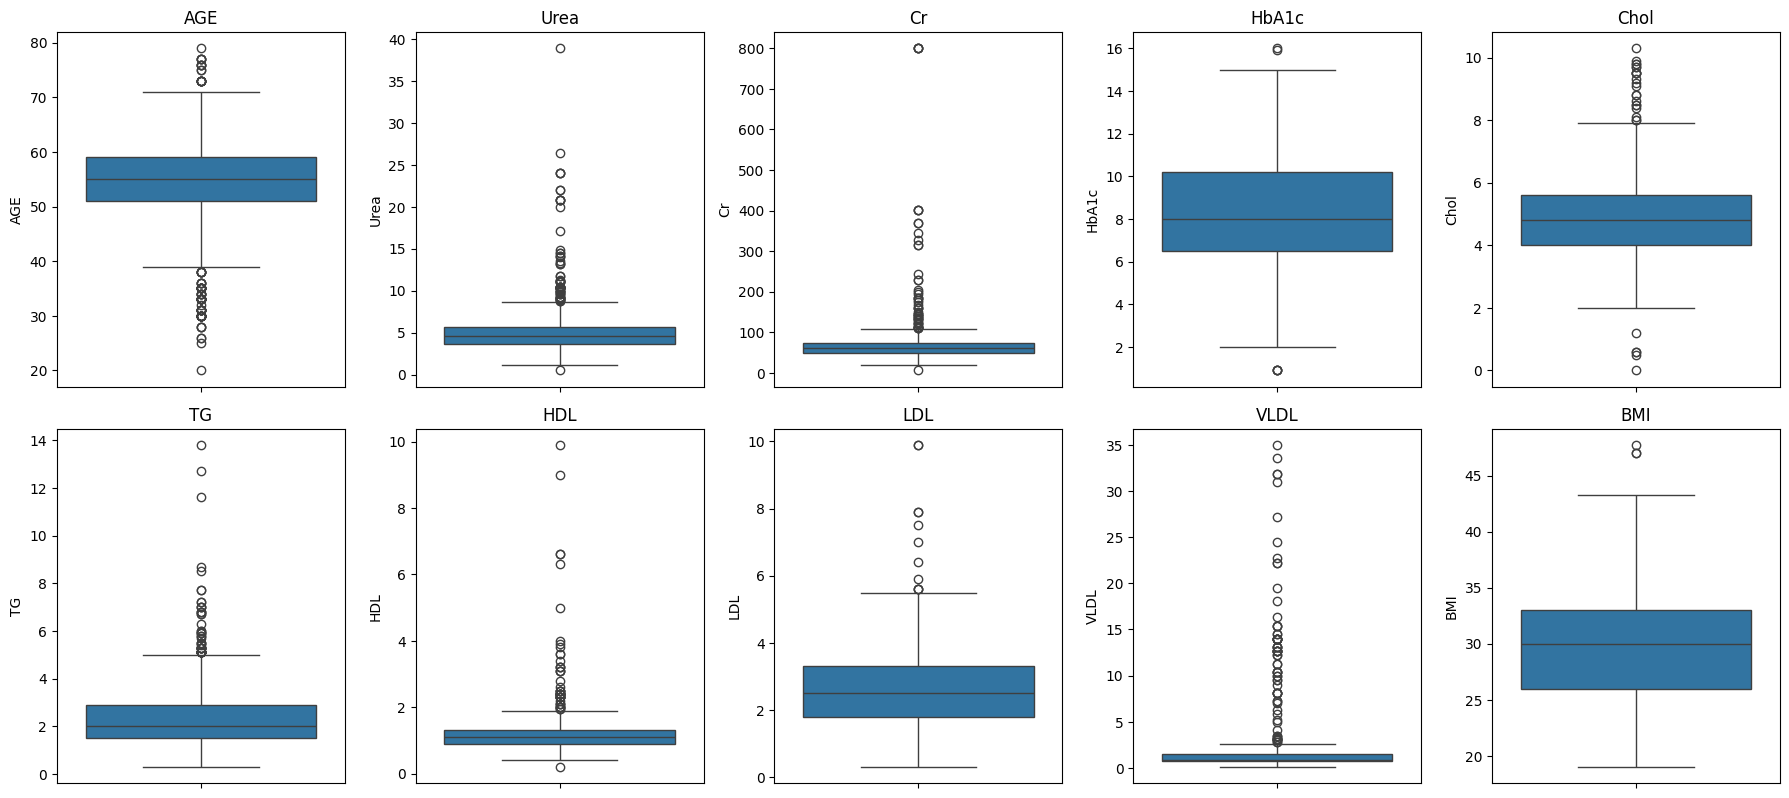

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

numerical_cols = [col for col in numerical_cols if col not in ['ID', 'No_Pation', 'CLASS_encoded']]

print(f"Numerical columns identified for outlier detection: {numerical_cols}")

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 5, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


Handling outliers using IQR method...
Outliers in 'AGE' capped. Lower bound: 39.00, Upper bound: 71.00
Outliers in 'Urea' capped. Lower bound: 0.70, Upper bound: 8.70
Outliers in 'Cr' capped. Lower bound: 10.50, Upper bound: 110.50
Outliers in 'HbA1c' capped. Lower bound: 0.95, Upper bound: 15.75
Outliers in 'Chol' capped. Lower bound: 1.60, Upper bound: 8.00
Outliers in 'TG' capped. Lower bound: -0.60, Upper bound: 5.00
Outliers in 'HDL' capped. Lower bound: 0.30, Upper bound: 1.90
Outliers in 'LDL' capped. Lower bound: -0.45, Upper bound: 5.55
Outliers in 'VLDL' capped. Lower bound: -0.50, Upper bound: 2.70
Outliers in 'BMI' capped. Lower bound: 15.50, Upper bound: 43.50

Box plots after outlier capping:


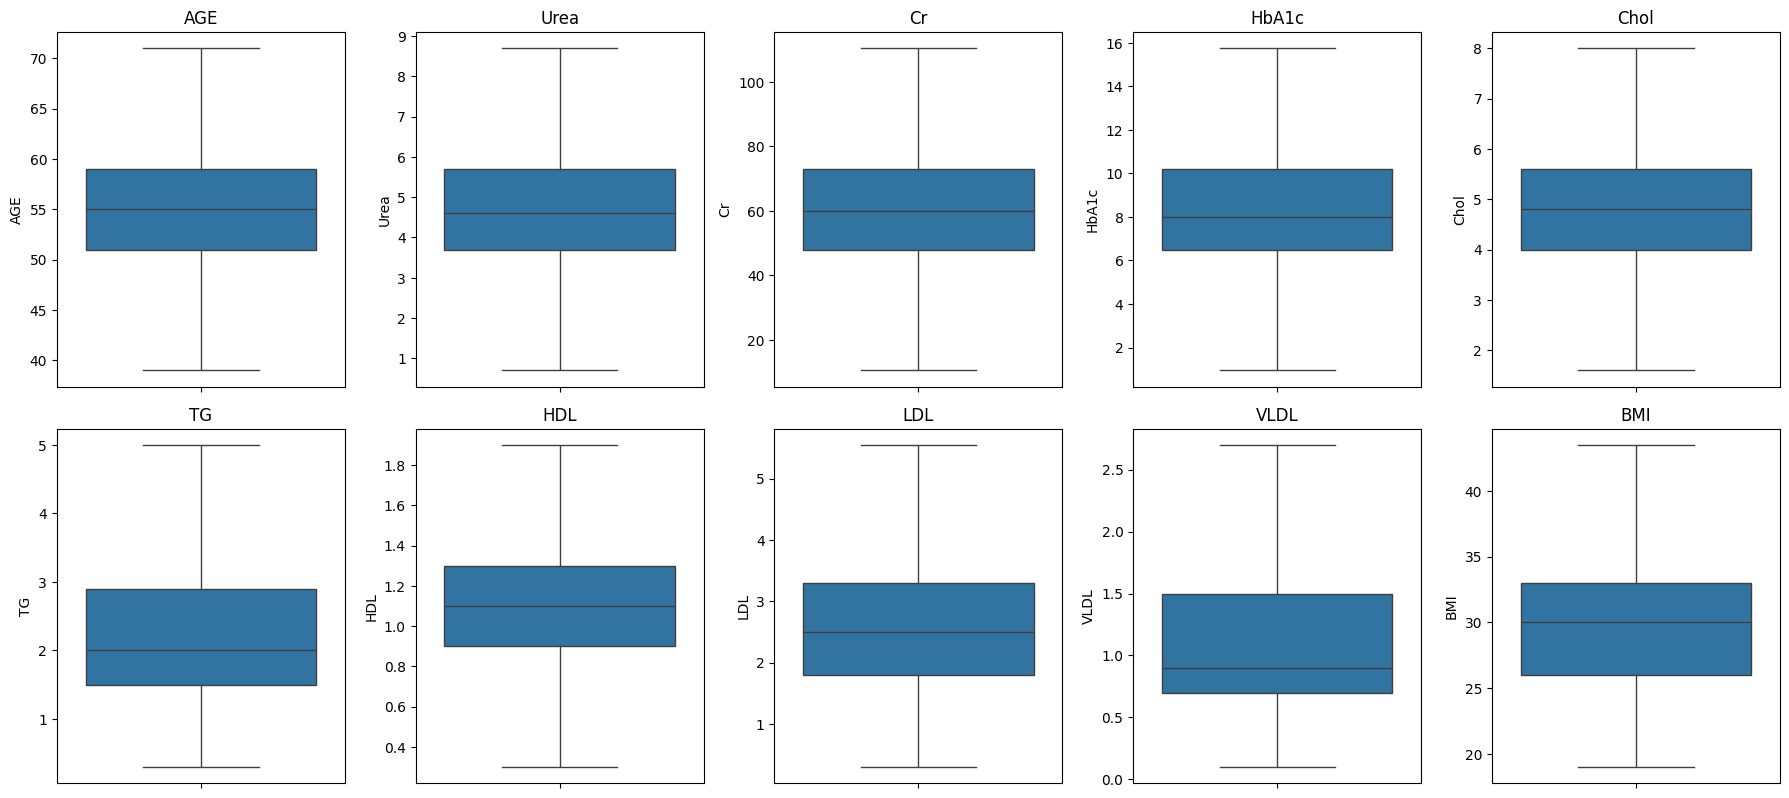


Descriptive statistics after outlier capping:
               AGE         Urea           Cr        HbA1c         Chol  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     53.986000     4.826843    62.345000     8.280960     4.843420   
std       7.363968     1.714231    20.297906     2.532224     1.210029   
min      39.000000     0.700000    10.500000     0.950000     1.600000   
25%      51.000000     3.700000    48.000000     6.500000     4.000000   
50%      55.000000     4.600000    60.000000     8.000000     4.800000   
75%      59.000000     5.700000    73.000000    10.200000     5.600000   
max      71.000000     8.700000   110.500000    15.750000     8.000000   

                TG          HDL          LDL        VLDL          BMI  
count  1000.000000  1000.000000  1000.000000  1000.00000  1000.000000  
mean      2.280610     1.142250     2.591640     1.14040    29.566770  
std       1.150887     0.348675     1.039511     0.62744     4.926358 

In [7]:
print('Handling outliers using IQR method...')

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    print(f"Outliers in '{col}' capped. Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

print('\nBox plots after outlier capping:')


plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 5, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

print('\nDescriptive statistics after outlier capping:')
print(df[numerical_cols].describe())

In [8]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

print('Applying Min-Max and Standard Scaling...')




df_minmax_scaled = df[numerical_cols].copy()
df_standard_scaled = df[numerical_cols].copy()


minmax_scaler = MinMaxScaler()
df_minmax_scaled[numerical_cols] = minmax_scaler.fit_transform(df_minmax_scaled[numerical_cols])
print('\nMin-Max Scaled Data (first 5 rows):')
print(df_minmax_scaled.head())
print('\nDescriptive statistics for Min-Max scaled features:')
print(df_minmax_scaled.describe())


standard_scaler = StandardScaler()
df_standard_scaled[numerical_cols] = standard_scaler.fit_transform(df_standard_scaled[numerical_cols])
print('\nStandard Scaled Data (first 5 rows):')
print(df_standard_scaled.head())
print('\nDescriptive statistics for Standard scaled features:')
print(df_standard_scaled.describe())


df_minmax_final = df.drop(columns=numerical_cols).copy()
df_minmax_final = pd.concat([df_minmax_final, df_minmax_scaled], axis=1)


df_standard_final = df.drop(columns=numerical_cols).copy()
df_standard_final = pd.concat([df_standard_final, df_standard_scaled], axis=1)

print('\nFirst 5 rows of DataFrame with Min-Max scaled features:')
print(df_minmax_final.head())

print('\nFirst 5 rows of DataFrame with Standard scaled features:')
print(df_standard_final.head())

Applying Min-Max and Standard Scaling...

Min-Max Scaled Data (first 5 rows):
       AGE   Urea     Cr     HbA1c      Chol        TG     HDL       LDL  \
0  0.34375  0.500  0.355  0.266892  0.406250  0.127660  1.0000  0.209524   
1  0.00000  0.475  0.515  0.266892  0.328125  0.234043  0.5000  0.342857   
2  0.34375  0.500  0.355  0.266892  0.406250  0.127660  1.0000  0.209524   
3  0.34375  0.500  0.355  0.266892  0.406250  0.127660  1.0000  0.209524   
4  0.00000  0.800  0.355  0.266892  0.515625  0.148936  0.3125  0.323810   

       VLDL       BMI  
0  0.153846  0.204082  
1  0.192308  0.163265  
2  0.153846  0.204082  
3  0.153846  0.204082  
4  0.115385  0.081633  

Descriptive statistics for Min-Max scaled features:
               AGE         Urea           Cr        HbA1c         Chol  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.468313     0.515855     0.518450     0.495335     0.506784   
std       0.230124     0.214279     0.202979  

In [13]:
import pandas as pd
df_adult = pd.read_csv('/content/adult.csv')
print("adult.csv loaded successfully into df_adult")
df_adult.head()

adult.csv loaded successfully into df_adult


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [14]:
print("\nDataFrame info:")
df_adult.info()

print("\nDescriptive statistics:")
print(df_adult.describe())

print("\nMissing values per column:")
print(df_adult.isnull().sum())


categorical_cols_adult = df_adult.select_dtypes(include=['object']).columns
print(f"\nIdentified categorical columns: {list(categorical_cols_adult)}")


for col in categorical_cols_adult:
    print(f"\nUnique values in '{col}': {df_adult[col].unique()}")
    print(f"Value counts for '{col}':\n{df_adult[col].value_counts()}")


DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

Descriptive statistics:
                age        fnlwgt 

In [15]:
import numpy as np

print('Handling missing values (represented by "?")...')


for col in ['workclass', 'occupation', 'native-country']:
    df_adult[col] = df_adult[col].replace('?', np.nan)
    print(f"'?' replaced with np.nan in '{col}'.")

print('\nMissing values after replacement:')
print(df_adult.isnull().sum())


for col in ['workclass', 'occupation', 'native-country']:
    mode_value = df_adult[col].mode()[0]
    df_adult[col] = df_adult[col].fillna(mode_value)
    print(f"Missing values in '{col}' imputed with mode: '{mode_value}'.")

print('\nMissing values after imputation:')
print(df_adult.isnull().sum())

print('\nUnique values in categorical columns after handling missing values:')
for col in ['workclass', 'occupation', 'native-country']:
    print(f"\nUnique values in '{col}': {df_adult[col].unique()}")
    print(f"Value counts for '{col}':\n{df_adult[col].value_counts()}")

Handling missing values (represented by "?")...
'?' replaced with np.nan in 'workclass'.
'?' replaced with np.nan in 'occupation'.
'?' replaced with np.nan in 'native-country'.

Missing values after replacement:
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64
Missing values in 'workclass' imputed with mode: 'Private'.
Missing values in 'occupation' imputed with mode: 'Prof-specialty'.
Missing values in 'native-country' imputed with mode: 'United-States'.

Missing values after imputation:
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race          

In [16]:
from sklearn.preprocessing import LabelEncoder

print('Cleaning and encoding categorical columns...')


categorical_cols_adult_updated = df_adult.select_dtypes(include=['object']).columns


for col in categorical_cols_adult_updated:
    if df_adult[col].dtype == 'object':
        df_adult[col] = df_adult[col].str.strip()
        print(f"Whitespace stripped from '{col}'.")


le_income = LabelEncoder()
df_adult['income_encoded'] = le_income.fit_transform(df_adult['income'])
print(f"\n'income' column label encoded. Mapping: {dict(zip(le_income.classes_, le_income.transform(le_income.classes_)))}")


df_adult = df_adult.drop('income', axis=1)


columns_to_onehot = [col for col in categorical_cols_adult_updated if col != 'income']

df_adult = pd.get_dummies(df_adult, columns=columns_to_onehot, drop_first=True)
print("\nRemaining categorical columns one-hot encoded.")

print('\nFirst 5 rows of the DataFrame after cleaning and encoding:')
print(df_adult.head())

Cleaning and encoding categorical columns...
Whitespace stripped from 'workclass'.
Whitespace stripped from 'education'.
Whitespace stripped from 'marital-status'.
Whitespace stripped from 'occupation'.
Whitespace stripped from 'relationship'.
Whitespace stripped from 'race'.
Whitespace stripped from 'gender'.
Whitespace stripped from 'native-country'.
Whitespace stripped from 'income'.

'income' column label encoded. Mapping: {'<=50K': np.int64(0), '>50K': np.int64(1)}

Remaining categorical columns one-hot encoded.

First 5 rows of the DataFrame after cleaning and encoding:
   age  fnlwgt  educational-num  capital-gain  capital-loss  hours-per-week  \
0   25  226802                7             0             0              40   
1   38   89814                9             0             0              50   
2   28  336951               12             0             0              40   
3   44  160323               10          7688             0              40   
4   18  103497        

Detecting and handling outliers in numerical features...
Numerical columns identified for outlier detection: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Box plots before outlier handling:


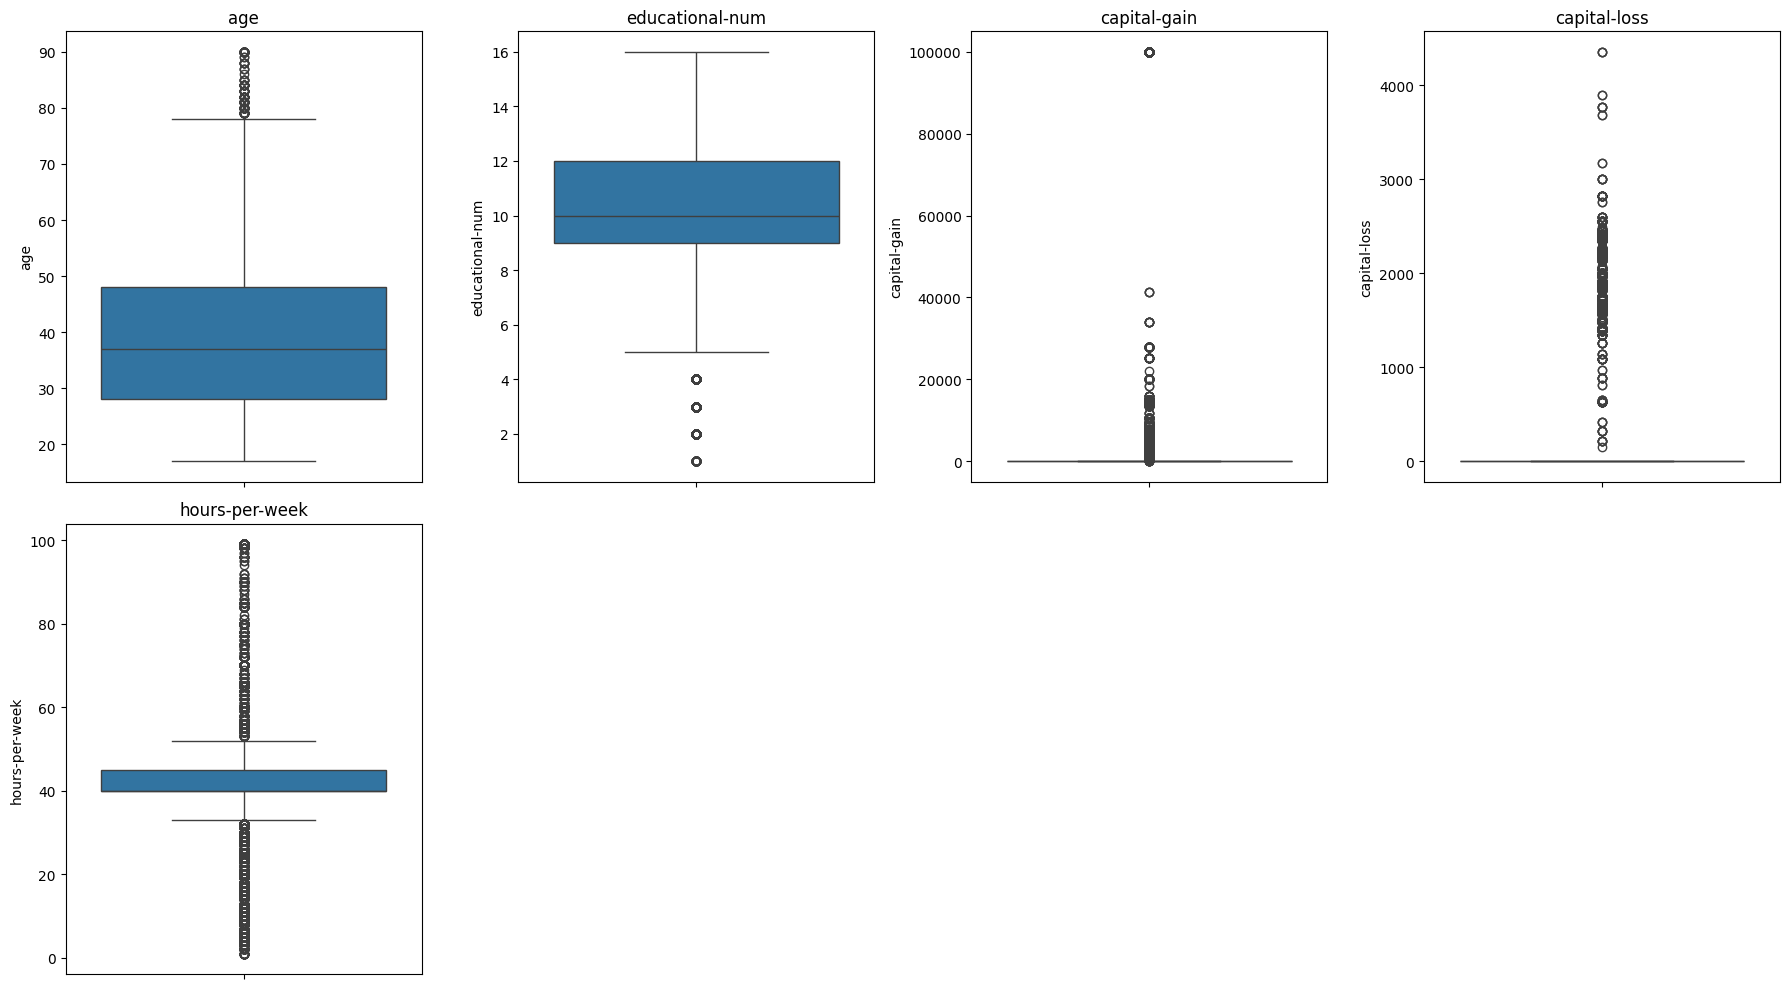


Handling outliers using IQR method...
Outliers in 'age' capped. Lower bound: -2.00, Upper bound: 78.00
Outliers in 'educational-num' capped. Lower bound: 4.50, Upper bound: 16.50
Outliers in 'capital-gain' capped. Lower bound: 0.00, Upper bound: 0.00
Outliers in 'capital-loss' capped. Lower bound: 0.00, Upper bound: 0.00
Outliers in 'hours-per-week' capped. Lower bound: 32.50, Upper bound: 52.50

Box plots after outlier capping:


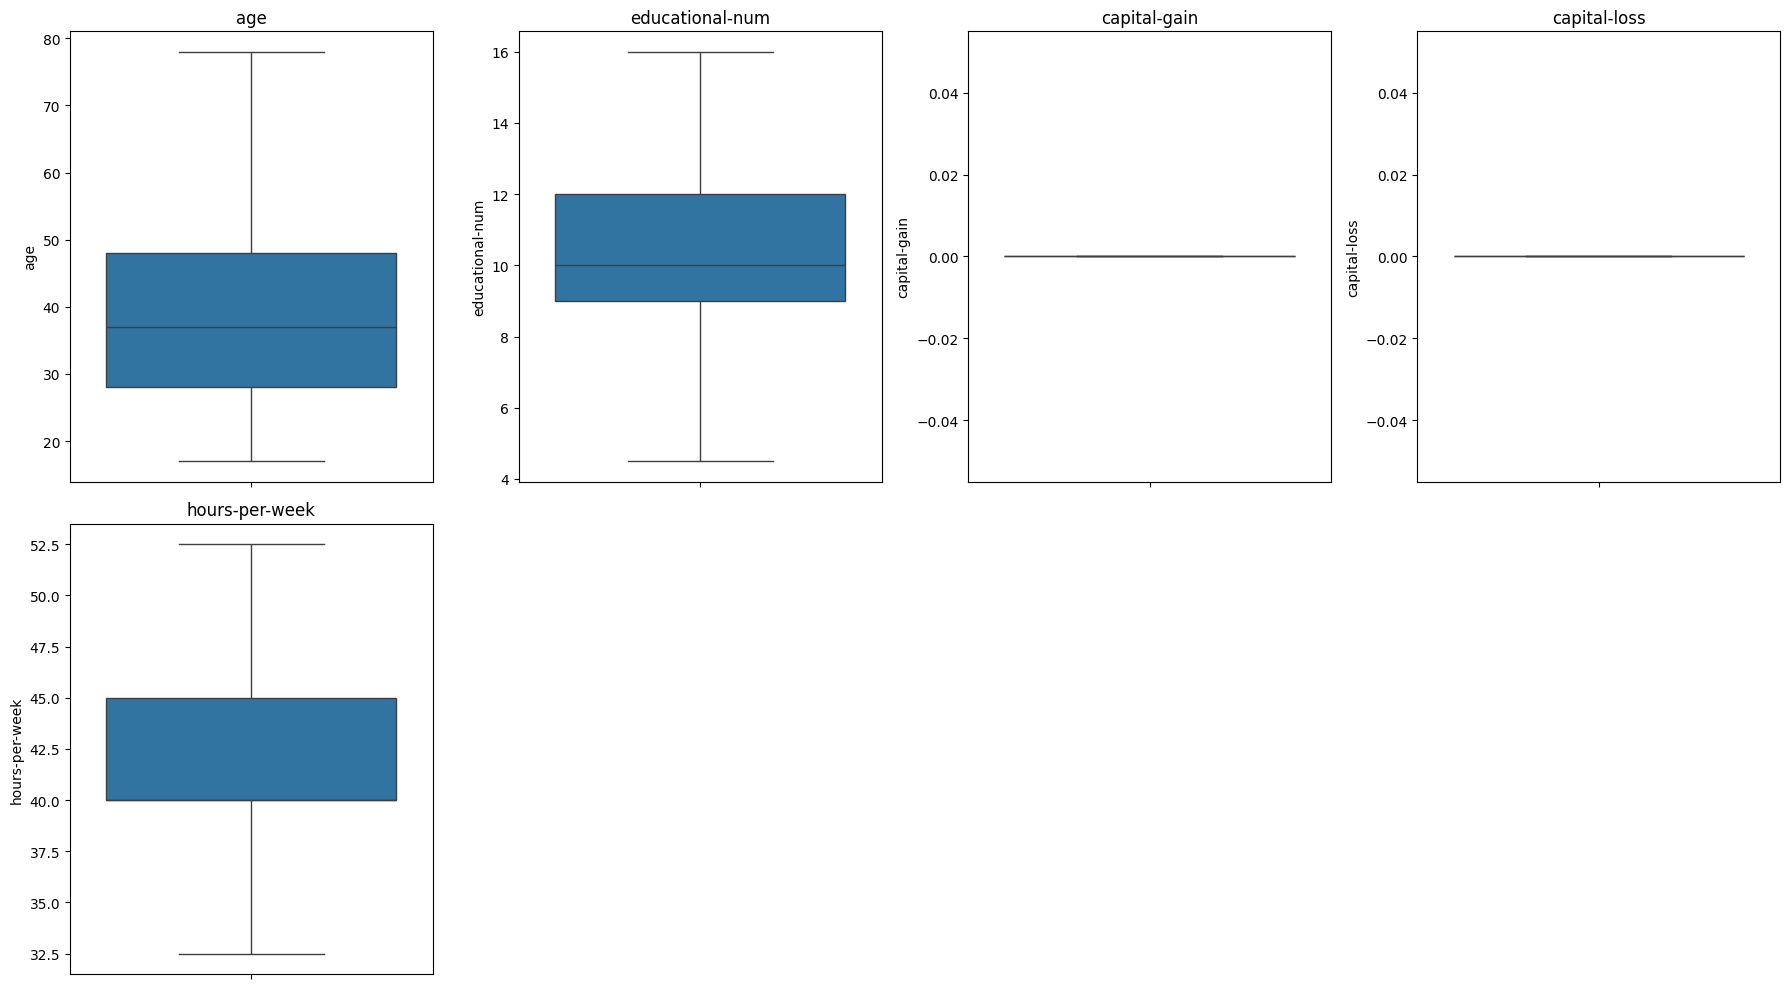


Descriptive statistics after outlier capping:
                age  educational-num  capital-gain  capital-loss  \
count  48842.000000     48842.000000       48842.0       48842.0   
mean      38.618566        10.122088           0.0           0.0   
std       13.630359         2.456895           0.0           0.0   
min       17.000000         4.500000           0.0           0.0   
25%       28.000000         9.000000           0.0           0.0   
50%       37.000000        10.000000           0.0           0.0   
75%       48.000000        12.000000           0.0           0.0   
max       78.000000        16.000000           0.0           0.0   

       hours-per-week  
count    48842.000000  
mean        41.192805  
std          6.184799  
min         32.500000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         52.500000  


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Detecting and handling outliers in numerical features...')


numerical_cols_adult = df_adult.select_dtypes(include=['int64', 'float64']).columns.tolist()

numerical_cols_adult = [col for col in numerical_cols_adult if col not in ['fnlwgt', 'income_encoded']]

print(f"Numerical columns identified for outlier detection: {numerical_cols_adult}")

print('\nBox plots before outlier handling:')
plt.figure(figsize=(18, 10))
for i, col in enumerate(numerical_cols_adult):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=df_adult[col])
    plt.title(col)
plt.tight_layout()
plt.show()

print('\nHandling outliers using IQR method...')
for col in numerical_cols_adult:
    Q1 = df_adult[col].quantile(0.25)
    Q3 = df_adult[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    df_adult[col] = df_adult[col].clip(lower=lower_bound, upper=upper_bound)
    print(f"Outliers in '{col}' capped. Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

print('\nBox plots after outlier capping:')
plt.figure(figsize=(18, 10))
for i, col in enumerate(numerical_cols_adult):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=df_adult[col])
    plt.title(col)
plt.tight_layout()
plt.show()

print('\nDescriptive statistics after outlier capping:')
print(df_adult[numerical_cols_adult].describe())

In [18]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

print('Applying Min-Max and Standard Scaling...')


numerical_cols_adult_scaling = df_adult.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols_adult_scaling = [col for col in numerical_cols_adult_scaling if col not in ['fnlwgt', 'income_encoded']]

print(f"Numerical columns identified for scaling: {numerical_cols_adult_scaling}")


df_adult_minmax_scaled_numerical = df_adult[numerical_cols_adult_scaling].copy()
df_adult_standard_scaled_numerical = df_adult[numerical_cols_adult_scaling].copy()


minmax_scaler = MinMaxScaler()
df_adult_minmax_scaled_numerical[numerical_cols_adult_scaling] = minmax_scaler.fit_transform(df_adult_minmax_scaled_numerical[numerical_cols_adult_scaling])
print('\nMin-Max Scaled Numerical Data (first 5 rows):')
print(df_adult_minmax_scaled_numerical.head())
print('\nDescriptive statistics for Min-Max scaled features:')
print(df_adult_minmax_scaled_numerical.describe())


standard_scaler = StandardScaler()
df_adult_standard_scaled_numerical[numerical_cols_adult_scaling] = standard_scaler.fit_transform(df_adult_standard_scaled_numerical[numerical_cols_adult_scaling])
print('\nStandard Scaled Numerical Data (first 5 rows):')
print(df_adult_standard_scaled_numerical.head())
print('\nDescriptive statistics for Standard scaled features:')
print(df_adult_standard_scaled_numerical.describe())


df_adult_minmax_final = df_adult.drop(columns=numerical_cols_adult_scaling).copy()
df_adult_minmax_final = pd.concat([df_adult_minmax_final, df_adult_minmax_scaled_numerical], axis=1)

df_adult_standard_final = df_adult.drop(columns=numerical_cols_adult_scaling).copy()
df_adult_standard_final = pd.concat([df_adult_standard_final, df_adult_standard_scaled_numerical], axis=1)

print('\nFirst 5 rows of DataFrame with Min-Max scaled features (including original non-numeric columns):')
print(df_adult_minmax_final.head())

print('\nFirst 5 rows of DataFrame with Standard scaled features (including original non-numeric columns):')
print(df_adult_standard_final.head())

Applying Min-Max and Standard Scaling...
Numerical columns identified for scaling: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Min-Max Scaled Numerical Data (first 5 rows):
        age  educational-num  capital-gain  capital-loss  hours-per-week
0  0.131148         0.217391           0.0           0.0           0.375
1  0.344262         0.391304           0.0           0.0           0.875
2  0.180328         0.652174           0.0           0.0           0.375
3  0.442623         0.478261           0.0           0.0           0.375
4  0.016393         0.478261           0.0           0.0           0.000

Descriptive statistics for Min-Max scaled features:
                age  educational-num  capital-gain  capital-loss  \
count  48842.000000     48842.000000       48842.0       48842.0   
mean       0.354403         0.488877           0.0           0.0   
std        0.223449         0.213643           0.0           0.0   
min        0.000000         0.